# **SAM Adaptation from Roboflow's Notebook**

This notebook is an Adaptation of Roboflow's "How to segment anything with SAM". After using all of Roboflow's initial model setup, I connect the notebook to my google drive to access the brain scans data produces by SamAnalysis.py to run the foundational model on them. **All results come from training on Google Colab T4 GPU**

## Before you start (Roboflow)

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that. In case of any problems navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `GPU`, and then click `Save`.

In [1]:
!nvidia-smi

Sun Nov 30 02:02:58 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   72C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

**NOTE:** To make it easier for us to manage datasets, images and models we create a `HOME` constant.

In [2]:
import os
HOME = os.getcwd()
print("HOME:", HOME)

HOME: /content


## Install Segment Anything Model (SAM) and other dependencies (Roboflow)

In [3]:
!pip install -q 'git+https://github.com/facebookresearch/segment-anything.git'

  Preparing metadata (setup.py) ... done


In [4]:
!pip install -q jupyter_bbox_widget roboflow dataclasses-json supervision==0.23.0

## Download SAM weights (Roboflow)

In [5]:
!mkdir -p {HOME}/weights
!wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth -P {HOME}/weights

In [6]:
import os

CHECKPOINT_PATH = os.path.join(HOME, "weights", "sam_vit_h_4b8939.pth")
print(CHECKPOINT_PATH, "; exist:", os.path.isfile(CHECKPOINT_PATH))

/content/weights/sam_vit_h_4b8939.pth ; exist: True


## Load Model (Roboflow)

In [7]:
import torch
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
MODEL_TYPE = "vit_h"

In [8]:
from segment_anything import sam_model_registry, SamPredictor
import torch
import cv2
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

model_type = "vit_h"
sam = sam_model_registry[model_type](checkpoint=CHECKPOINT_PATH).to(device)
predictor = SamPredictor(sam)

Using device: cuda


In [9]:
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator, SamPredictor

sam = sam_model_registry[MODEL_TYPE](checkpoint=CHECKPOINT_PATH).to(device=DEVICE)

In [10]:
mask_generator = SamAutomaticMaskGenerator(sam)

##Mount Drive
Now after setting up SAM, its time to mount to Google Drive and find the slices produced from SamAnalysis.py
**Must Change to match where you stored sam_slices from SamAnalysis.py**

In [26]:
from google.colab import drive
drive.mount('/content/drive')

DATA_ROOT = "/content/drive/MyDrive/sam_slices"
print("DATA_ROOT:", DATA_ROOT)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
DATA_ROOT: /content/drive/MyDrive/sam_slices


## Helper functions

In [27]:
import matplotlib.pyplot as plt
import pandas as pd
import glob
import os


def get_box_from_mask(mask):
    #Return [x0, y0, x1, y1] bounding box around mask pixels
    ys, xs = np.where(mask > 0)
    if len(xs) == 0:
        return None
    x0, x1 = xs.min(), xs.max()
    y0, y1 = ys.min(), ys.max()
    return np.array([x0, y0, x1, y1])

def dice_score(gt, pred):
    gt = (gt > 0)
    pred = (pred > 0)
    intersection = np.logical_and(gt, pred).sum()
    gt_sum = gt.sum()
    pred_sum = pred.sum()
    if gt_sum + pred_sum == 0:
        return 1.0  # no tumor in either → perfect match for this slice
    return 2.0 * intersection / float(gt_sum + pred_sum)

def iou_score(gt, pred):
    gt = (gt > 0)
    pred = (pred > 0)
    intersection = np.logical_and(gt, pred).sum()
    union = np.logical_or(gt, pred).sum()
    if union == 0:
        return 1.0
    return intersection / float(union)


Call this function on each modality, so SAM can be runned on each mode and the results can be compared to eachother

In [13]:
def run_sam_on_folder(data_dir):
    img_dir = f"{data_dir}/images"
    mask_dir = f"{data_dir}/masks"

    image_paths = sorted(glob.glob(os.path.join(img_dir, "*.png")))
    print("Folder:", data_dir)
    print("Num slices:", len(image_paths))

    results = []

    for img_path in image_paths:
        fname = os.path.basename(img_path)
        mask_path = os.path.join(mask_dir, fname.replace(".png", "_mask.png"))

        # load image & GT mask
        image_bgr = cv2.imread(img_path)
        image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

        gt_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        gt_mask_bin = (gt_mask > 0).astype(np.uint8)

        # bounding box from GT
        box = get_box_from_mask(gt_mask_bin)
        if box is None:
            continue

        # SAM prediction
        predictor.set_image(image_rgb)
        masks, scores, logits = predictor.predict(
            box=box[None, :],
            multimask_output=False
        )
        sam_mask = masks[0].astype(np.uint8)

        results.append((fname, gt_mask_bin, sam_mask, image_rgb))

    # convert to DataFrame & compute metrics
    rows = []
    for fname, gt_mask_bin, sam_mask, _ in results:
        d = dice_score(gt_mask_bin, sam_mask)
        i = iou_score(gt_mask_bin, sam_mask)
        rows.append({
            "slice_id": fname,
            "dice_sam": d,
            "iou_sam": i,
            "gt_tumor_pixels": int(gt_mask_bin.sum()),
            "sam_tumor_pixels": int(sam_mask.sum()),
        })

    df = pd.DataFrame(rows)
    print("Mean Dice:", df["dice_sam"].mean())
    print("Mean IoU :", df["iou_sam"].mean())
    print()
    return df, results

In [14]:
flair_dir = f"{DATA_ROOT}/flair"
t1_dir    = f"{DATA_ROOT}/t1"
t1ce_dir  = f"{DATA_ROOT}/t1ce"
t2_dir    = f"{DATA_ROOT}/t2"

df_sam_flair, results_flair = run_sam_on_folder(flair_dir)
df_sam_t1,    results_t1    = run_sam_on_folder(t1_dir)
df_sam_t1ce,  results_t1ce  = run_sam_on_folder(t1ce_dir)
df_sam_t2,    results_t2    = run_sam_on_folder(t2_dir)


Folder: /content/drive/MyDrive/sam_slices/flair
Num slices: 127
Mean Dice: 0.8156551398392285
Mean IoU : 0.727335934517806

Folder: /content/drive/MyDrive/sam_slices/t1
Num slices: 127
Mean Dice: 0.7079342268942811
Mean IoU : 0.5779021259072576

Folder: /content/drive/MyDrive/sam_slices/t1ce
Num slices: 127
Mean Dice: 0.7131771014387597
Mean IoU : 0.5833356047468503

Folder: /content/drive/MyDrive/sam_slices/t2
Num slices: 127
Mean Dice: 0.7615878056628662
Mean IoU : 0.6531256351938032



##Results

In [15]:
summary_rows = [
    {"modality": "FLAIR", "mean_dice": df_sam_flair["dice_sam"].mean(),
                         "mean_iou":  df_sam_flair["iou_sam"].mean()},
    {"modality": "T1",    "mean_dice": df_sam_t1["dice_sam"].mean(),
                         "mean_iou":  df_sam_t1["iou_sam"].mean()},
    {"modality": "T1ce",  "mean_dice": df_sam_t1ce["dice_sam"].mean(),
                         "mean_iou":  df_sam_t1ce["iou_sam"].mean()},
    {"modality": "T2",    "mean_dice": df_sam_t2["dice_sam"].mean(),
                         "mean_iou":  df_sam_t2["iou_sam"].mean()},
]

df_mod_summary = pd.DataFrame(summary_rows)
df_mod_summary


,modality,mean_dice,mean_iou
0,FLAIR,0.815655,0.727336
1,T1,0.707934,0.577902
2,T1ce,0.713177,0.583336
3,T2,0.761588,0.653126


##Histogram


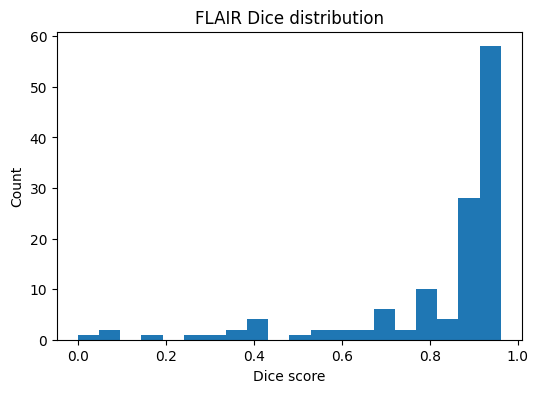

In [24]:
# Simple histogram for FLAIR
plt.figure(figsize=(6, 4))
plt.hist(df_sam_flair["dice_sam"], bins=20)
plt.title("FLAIR Dice distribution")
plt.xlabel("Dice score")
plt.ylabel("Count")
plt.show()


#Slice Visual

Visualizing slice: TCGA-DU-7298_z062.png with GT tumor pixels = 3997


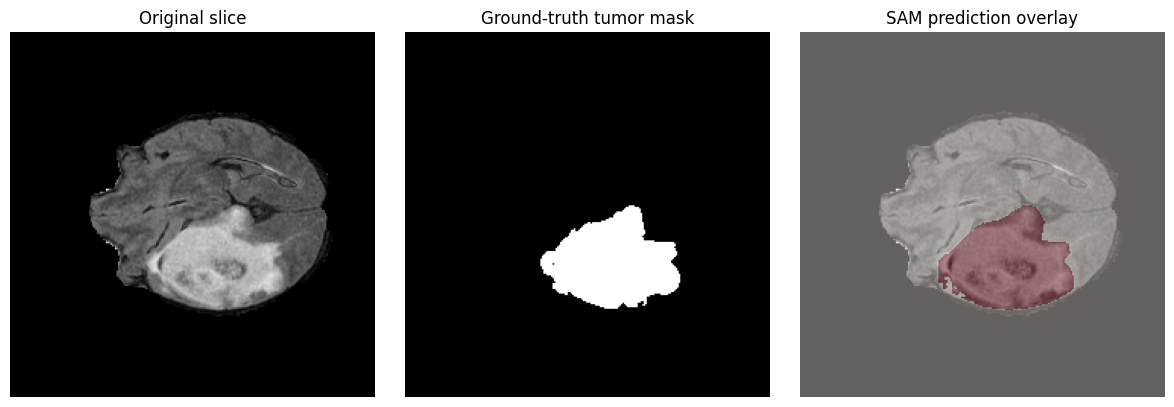

In [25]:
#Slice with biggest tumor
idx_big = df_sam_flair["gt_tumor_pixels"].idxmax()
example_id = df_sam_flair.loc[idx_big, "slice_id"]
print("Visualizing slice:", example_id,
      "with GT tumor pixels =", df_sam_flair.loc[idx_big, "gt_tumor_pixels"])

example = None
for fname, gt_mask_bin, sam_mask, image_rgb in results_flair:
    if fname == example_id:
        example = (fname, gt_mask_bin, sam_mask, image_rgb)
        break

if example is None:
    print("Slice not found!")
else:
    fname, gt_mask_bin, sam_mask, image_rgb = example

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    # Original slice
    axes[0].imshow(image_rgb, cmap="gray")
    axes[0].set_title("Original slice")
    axes[0].axis("off")

    # Ground-truth tumor mask
    axes[1].imshow(gt_mask_bin, cmap="gray")
    axes[1].set_title("Ground-truth tumor mask")
    axes[1].axis("off")

    # SAM prediction overlay
    axes[2].imshow(image_rgb, cmap="gray")
    axes[2].imshow(sam_mask, alpha=0.4, cmap="Reds")
    axes[2].set_title("SAM prediction overlay")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

